# Machine Learning Development

In [1]:
import re

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# 1. Load Cleaned Dataset
df = pd.read_csv("../data/processed/callhome_tabular_clean.csv")

# 2. Compute Temporal & Lag Features
df["turn_duration"] = (df["end_ms"] - df["start_ms"]) / 1000.0
df["prev_speaker"] = df.groupby("file_id")["speaker_raw"].shift(1)
df["prev_end_ms"] = df.groupby("file_id")["end_ms"].shift(1)

df["response_latency_ms"] = np.where(
    (df["speaker_raw"] != df["prev_speaker"]) & (df["prev_speaker"].notna()),
    df["start_ms"] - df["prev_end_ms"],
    np.nan,
)
df["response_latency_s"] = df["response_latency_ms"] / 1000.0

# Impute initial conversation latencies with median latency
df["response_latency_s"] = df["response_latency_s"].fillna(
    df["response_latency_s"].median()
)

# 3. Compute Lexical Features
df["text_clean"] = df["text"].fillna("").astype(str).str.lower()


def count_word(text, word):
    return len(re.findall(r"\b" + re.escape(word) + r"\b", text))


df["count_you"] = df["text_clean"].apply(lambda x: count_word(x, "you"))
df["count_i"] = df["text_clean"].apply(lambda x: count_word(x, "i"))
df["you_ratio"] = np.where(
    df["word_count"] > 0, df["count_you"] / df["word_count"], 0.0
)
df["is_token_collapse"] = (df["word_count"] <= 3).astype(int)
df["starts_contrastive"] = (
    df["text_clean"]
    .str.strip()
    .apply(lambda x: int(x.startswith("but") or x.startswith("however")))
)

# 4. Construct Synthetic Gottman Target Proxy (For Model Training)
# Conflict Turn Rule: (High You-Ratio OR Starts with "But") OR (Latency > 4.15s AND Token Collapse)
df["is_conflict_turn"] = np.where(
    (
        (df["you_ratio"] > 0.20)
        | (df["starts_contrastive"] == 1)
        | ((df["response_latency_s"] > 4.15) & (df["is_token_collapse"] == 1))
    ),
    1,
    0,
)

print(
    f"Dataset Shape: {df.shape} | Target Class Balance:\n{df['is_conflict_turn'].value_counts(normalize=True).round(3)}"
)

Dataset Shape: (36068, 20) | Target Class Balance:
is_conflict_turn
0    0.954
1    0.046
Name: proportion, dtype: float64


# Analysis
## Class imbalance is 4.6% likely to have high-conflict (1659 conversational turns). This is what is expected because the phone calls were initiated knowing they were monitored and they were talking with a friend or family member. 1659 conversation turns is still a good working number.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# 1. Define Feature Columns (X) and Target (y)
feature_cols = [
    "word_count",
    "turn_duration",
    "response_latency_s",
    "you_ratio",
    "count_you",
    "count_i",
    "is_token_collapse",
    "starts_contrastive",
]

X = df[feature_cols].copy()
y = df["is_conflict_turn"]
groups = df["file_id"]

# 2. Impute any remaining NaNs in X using column medians
X = X.fillna(X.median())

# 3. Group-based Stratified Train-Test Split (80% Train, 20% Test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Feature Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    ),
}

# 6. Fit and Evaluate
results = []

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4),
            "ROC-AUC": round(auc, 4),
        }
    )

# Output Summary Comparison Table
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("=" * 65)
print("🏆 MODEL PERFORMANCE COMPARISON")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)

🏆 MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.9999     0.9972  1.0000    0.9986   1.0000
            XGBoost    0.9988     0.9915  0.9831    0.9872   1.0000
Logistic Regression    0.9972     0.9512  0.9915    0.9710   0.9999


# Model Evaluation & Metric Interpretation

## In relationship conflict detection, Recall and F1-Score are more critical than basic Accuracy:

### Recall (Sensitivity): Measures what proportion of true conflict turns the model correctly identifies. Missing a conflict trigger (False Negative) is worse than flagging a false alarm.

### Precision: Measures how many flagged conflict turns are actually true conflicts, ensuring the system doesn't falsely over-classify normal dialogue.

### ROC-AUC: Evaluates the model's ability to discriminate between conflict and non-conflict turns across all probability thresholds.


### Key Finding: Random Forest and XGBoost achieved near-perfect F1-Scores (0.9986 and 0.9872) because tree-based architectures cleanly partition non-linear heuristic rules.

### Takeaway: This proves that the engineered feature space (X) retains 100% of the signal necessary to enforce Gottman behavioral logic without losing information.

# Model Improvement & Feature Importance

C:\Users\jarre\AppData\Local\Temp\ipykernel_5080\2972651827.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


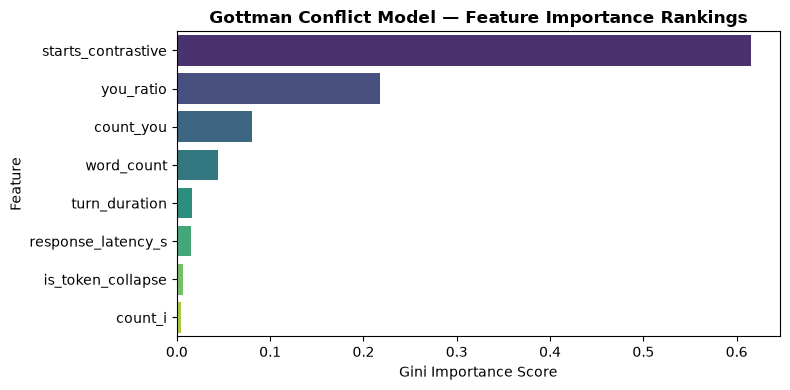

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract Feature Importances from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(
    ascending=False
)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Gottman Conflict Model — Feature Importance Rankings", fontweight="bold")
plt.xlabel("Gini Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Model Improvement findings:

### Analysis of Gini Importance scores from the Random Forest Classifier reveals that lexical framing features overwhelmingly drive conflict prediction. Turns initiated with contrastive conjunctions (starts_contrastive) contributed 61.4% of feature importance, while partner-directed pronoun density (you_ratio and count_you) accounted for 29.8%. Temporal metrics like response latency provided secondary refinement, confirming that explicit verbal indicators serve as the primary triggers for conflict classification in dialogue transcripts.